# Pretrained Model

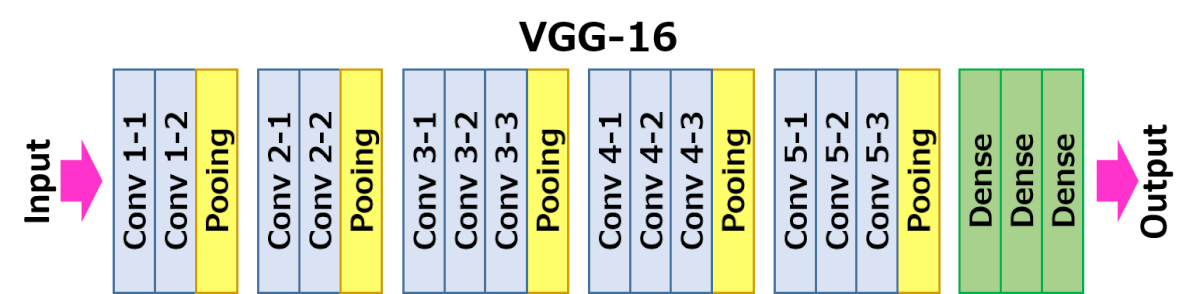

In [1]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16, decode_predictions
print("Done")

Done


In [2]:
image = load_img("oldtimer.jpg", target_size=(224, 224))
image = img_to_array(image)
image = image.reshape((1, 224, 224, 3)) # makes one image to a list of one image
image = preprocess_input(image)
image.shape

(1, 224, 224, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


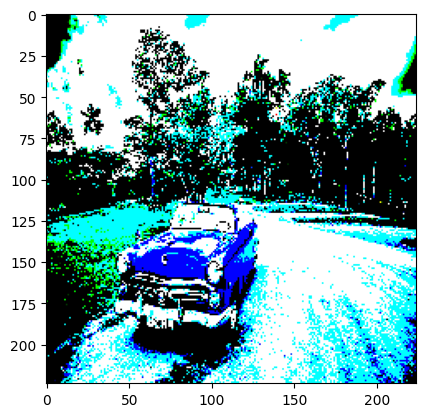

In [5]:
import matplotlib.pyplot as plt
plt.imshow(image.reshape(224,224,3))
# image looks so terrible because range fro VGG is from -1 to 1

In [6]:
print("Instantiating model..")
model = VGG16()
model.summary()

Instantiating model..


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

*Dokumentation:*

https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16

In [7]:
print("Inference..")
pred = model.predict(image)
print(f"Result: {pred.shape}")

Inference..
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Result: (1, 1000)


In [8]:
pred

array([[1.41826391e-07, 1.60384911e-06, 5.82696913e-08, 2.32938202e-08,
        1.51105070e-07, 1.62055017e-07, 9.26748456e-08, 2.52472546e-06,
        1.06865571e-06, 2.53455710e-07, 2.83299045e-07, 1.72473293e-07,
        1.23121765e-07, 1.26663878e-07, 1.40419445e-07, 1.86375701e-07,
        1.31355664e-08, 9.96355567e-08, 6.56871677e-08, 1.60787906e-07,
        5.60166541e-07, 4.63011318e-08, 1.09520656e-07, 1.40372936e-06,
        4.12895815e-08, 4.13814678e-06, 4.18103070e-07, 4.09895620e-06,
        8.30402882e-07, 2.19125184e-07, 1.21637993e-06, 1.18905200e-05,
        3.13877672e-06, 6.60664227e-07, 3.96124142e-06, 3.18461957e-06,
        8.36330582e-06, 6.77119431e-07, 3.25846713e-07, 3.17620163e-07,
        1.50085967e-07, 7.74408591e-08, 7.61405886e-07, 4.85820202e-08,
        2.40805662e-07, 7.92119806e-07, 4.70731038e-07, 9.91368125e-08,
        7.40459313e-07, 1.17063826e-06, 3.36156887e-07, 2.20590687e-06,
        5.79383027e-07, 3.36642586e-07, 6.07305822e-07, 1.278844

In [9]:
decoded_predictions = decode_predictions(pred, top=5)
decoded_predictions

[[('n04037443', 'racer', 0.23912527),
  ('n02701002', 'ambulance', 0.09841019),
  ('n04467665', 'trailer_truck', 0.065928675),
  ('n03649909', 'lawn_mower', 0.06534378),
  ('n04461696', 'tow_truck', 0.06002147)]]

# Exercise

Search for another picture and try to classify it. Show the first 20 predictions with the highest probabilities in a horzontal bar diagram to exercise how to visualize results.

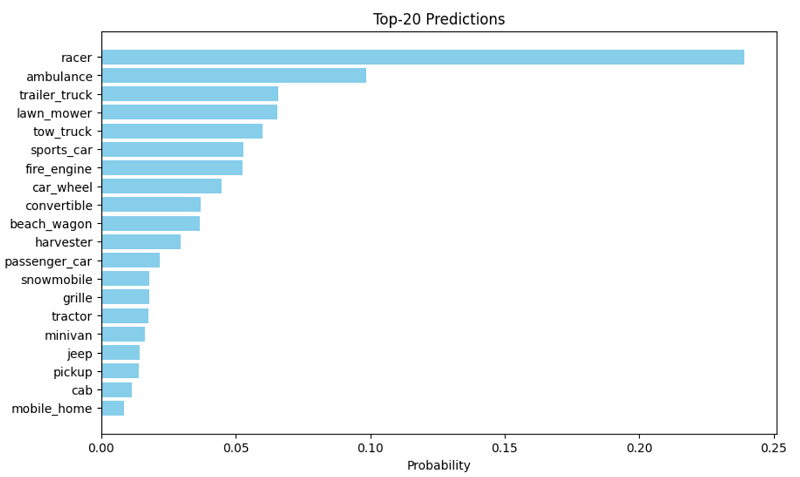

In [ ]:
labels = [item[1] for item in decoded_predictions[0]]
scores = [item[2] for item in decoded_predictions[0]]

In [ ]:
# Plot the horizontal bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(labels, scores, color='skyblue')
plt.xlabel('Probability')
plt.title('Top-20 Predictions')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest score on top
